<a href="https://colab.research.google.com/github/MAvRK7/Neural-Nets-Learning/blob/main/GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implementing the transformer arch introduced by Vasvani et al. https://arxiv.org/pdf/1706.03762 2017 for translation can be applied eleswhere too.

Using this to predict the next char using the Shakespeare dataset

So, we are given a chunk of chars (given some context of chars in the past) the transformer NN will look at that and predict the next char

**Richard cried Char** transformer will say "g" is next

In [ ]:
import torch
import torch.nn.functional as F

In [ ]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2025-12-09 08:05:04--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  --.-KB/s    in 0.03s   

2025-12-09 08:05:04 (31.7 MB/s) - ‘input.txt’ saved [1115394/1115394]



In [ ]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
print("length of dataset in characters: ", len(text))

length of dataset in characters:  1115394


In [ ]:
# let's look at the first 1000 characters
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [ ]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


So we have 65 possible characters

Now, coming to the tokenisation. We can either have more chars totally or less tokens per char

In [ ]:
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("hii there"))
print(decode(encode("hii there")))
# we have an encoder and a decoder=> eff. a tokenizer

[46, 47, 47, 1, 58, 46, 43, 56, 43]
hii there


Eg openAI uses tiktoken which has 50k total tokens [codebook] (we have 64) so they would encode hii there to just 3 [seq of ints]nums (compared to 9 of ours)

Called as codebook sequence length tradeoff

In [ ]:
print(chars)

['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
# lets tokenize the entire text of Shakespeare

# let's now encode the entire text dataset and store it into a torch.Tensor
import torch # we use PyTorch: https://pytorch.org
data = torch.tensor(encode(text), dtype=torch.long)
print(data.shape, data.dtype)
print(data[:1000]) # the 1000 characters we looked at earier will to the GPT look like this

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

In [ ]:
# Let's now split up the data into train and validation sets
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

Now, we will give only parts of the text seq to the transfrmr model, we WONT give the whole text at once (too comp expensive)

We give chunk wise (the model trains chunk wise). These chunks have max lengths AKA Context lenght

In [ ]:
# lets call the max length of the chunks as block_size
block_size = 8
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58])

These are the first 9 chars in the seq. (they are sequential). These 9 chars have 8 exaples in them

eg 1,2,3

the sub egs we have is 1-2, 1-2-3 (so we have 2 sub egs in a lenght of 3)

Thats why +1

So we make the transformer train on every one of these positions -18, 47, 56... so we have 8 individual egs

Below are the 8 egs hidden in the chunk of 9 chars

In [ ]:
x = train_data[:block_size]
y = train_data[1:block_size+1]
for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print(f"when input is {context} the target: {target}")

when input is tensor([18]) the target: 47
when input is tensor([18, 47]) the target: 56
when input is tensor([18, 47, 56]) the target: 57
when input is tensor([18, 47, 56, 57]) the target: 58
when input is tensor([18, 47, 56, 57, 58]) the target: 1
when input is tensor([18, 47, 56, 57, 58,  1]) the target: 15
when input is tensor([18, 47, 56, 57, 58,  1, 15]) the target: 47
when input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target: 58


This is done not just for efficiency but to enable to transformer to work with as little as 1 char input as context

In [ ]:
torch.manual_seed(1337)
batch_size = 4 # how many independent sequences will we process in parallel?
block_size = 8 # what is the maximum context length for predictions?

def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    return x, y

xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

print('----')

for b in range(batch_size): # batch dimension
    for t in range(block_size): # time dimension
        context = xb[b, :t+1]
        target = yb[b,t]
        print(f"when input is {context.tolist()} the target: {target}")

inputs:
torch.Size([4, 8])
tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])
targets:
torch.Size([4, 8])
tensor([[43, 58,  5, 57,  1, 46, 43, 39],
        [53, 56,  1, 58, 46, 39, 58,  1],
        [58,  1, 58, 46, 39, 58,  1, 46],
        [17, 27, 10,  0, 21,  1, 54, 39]])
----
when input is [24] the target: 43
when input is [24, 43] the target: 58
when input is [24, 43, 58] the target: 5
when input is [24, 43, 58, 5] the target: 57
when input is [24, 43, 58, 5, 57] the target: 1
when input is [24, 43, 58, 5, 57, 1] the target: 46
when input is [24, 43, 58, 5, 57, 1, 46] the target: 43
when input is [24, 43, 58, 5, 57, 1, 46, 43] the target: 39
when input is [44] the target: 53
when input is [44, 53] the target: 56
when input is [44, 53, 56] the target: 1
when input is [44, 53, 56, 1] the target: 58
when input is [44, 53, 56, 1, 58] the target: 46
when input is [44, 53

In [ ]:
# generate a small batch of data of inputs x and targets y
data = train_data # Corrected: 'train_data' tensor instead of string 'train'
ix = torch.randint(len(data) - block_size, (batch_size,))
x = torch.stack([data[i:i+block_size] for i in ix])
y = torch.stack([data[i+1:i+block_size+1] for i in ix])
print("data:",data)
print("len of train data:",len(data))
print("the indices:",ix)
print(x)
print("----")
print(y)

data: tensor([18, 47, 56,  ..., 43, 56, 43])
len of train data: 1003854
the indices: tensor([971401, 579495, 193625, 348340])
tensor([[57, 43, 60, 43, 52,  1, 63, 43],
        [60, 43, 42,  8,  0, 25, 63,  1],
        [56, 42,  5, 57,  1, 57, 39, 49],
        [43, 57, 58, 63,  6,  1, 58, 46]])
----
tensor([[43, 60, 43, 52,  1, 63, 43, 39],
        [43, 42,  8,  0, 25, 63,  1, 45],
        [42,  5, 57,  1, 57, 39, 49, 43],
        [57, 58, 63,  6,  1, 58, 46, 47]])


In [ ]:
print(xb) # our input to the transformer

tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


Implementing a bigram model

In [ ]:
'''
This will give an error Expected target size [4, 65], got [4, 8]


import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C) [Batch=4, Time=8, Channel=65]

        #lets add a loss function
        loss = F.cross_entropy(logits, targets)

        return logits, loss

m = BigramLanguageModel(vocab_size)
logits,loss = m(xb,yb)
print(loss.shape)

'''

'\nThis will give an error Expected target size [4, 65], got [4, 8]\n\n\nimport torch\nimport torch.nn as nn\nfrom torch.nn import functional as F\ntorch.manual_seed(1337)\n\nclass BigramLanguageModel(nn.Module):\n\n    def __init__(self, vocab_size):\n        super().__init__()\n        # each token directly reads off the logits for the next token from a lookup table\n        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)\n\n    def forward(self, idx, targets):\n\n        # idx and targets are both (B,T) tensor of integers\n        logits = self.token_embedding_table(idx) # (B,T,C) [Batch=4, Time=8, Channel=65]\n\n        #lets add a loss function\n        loss = F.cross_entropy(logits, targets)\n\n        return logits, loss\n\nm = BigramLanguageModel(vocab_size)\nlogits,loss = m(xb,yb)\nprint(loss.shape)\n\n'

The logits (B,T,C) is (4,8,64) BUT the targets (B,T) is (4,8)

In logits:
* B: 4 independent sequences
* T: 8 separate prediction points (the block size)
* C: 64 different votes the model has for the output char

But the predictions just have:
* B: Independent seq
* T: 8 separate targets

It must be: logits (32,64) and targets (32) COZ 8*4

This is what we want, but pytorch wants B,C,T and not B,T,C so we need to fix it

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size) #the embedding table is poplatd with random values as of now
        #nn.embedding just creates a matrix having 0,1,2,3...64 in both the rows and cols

    def forward(self, idx, targets):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C) [Batch=4, Time=8, Channel=65]
        # this converts xb from 4,8 to 4,8,65 as every number from xb will go and pluck out that row from the embeding table
        #eg the 1st num in xb is 24, this will be replaced by the

        B,T,C = logits.shape #give names to the shape
        logits = logits.view(B*T,C) #make it 32,64 from 4,8,64 (stretch it vertically)
        targets = targets.view(B*T) #make it [32] from 4,8
        loss = F.cross_entropy(logits, targets)

        return logits, loss

m = BigramLanguageModel(vocab_size)
logits,loss = m(xb,yb)
print(logits.shape)
print(loss)

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)


we are expecting the loss to be -ln(1/65) which is 4.17, but we're getting 4.87; so we're guessing wrong initially

But were able to judge the quality of data (we got the loss)

Now, lets also generate from the model

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)

class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx and targets are both (B,T) tensor of integers
        logits = self.token_embedding_table(idx) # (B,T,C)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    #NEW
    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # get the predictions
            logits, loss = self(idx)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx
        # so it goes like (B,T+1) then (B,T+2)...until max_new_tokens

m = BigramLanguageModel(vocab_size)
logits, loss = m(xb, yb)
print(logits.shape)
print(loss)

print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))
#it starts with 0, which is a "new line" char

torch.Size([32, 65])
tensor(4.8786, grad_fn=<NllLossBackward0>)

SKIcLT;AcELMoTbvZv C?nq-QE33:CJqkOKH-q;:la!oiywkHjgChzbQ?u!3bLIgwevmyFJGUGp
wnYWmnxKWWev-tDqXErVKLgJ


In [ ]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

#we're using Adam instead of Stocastic Grad desent (SGD)

In [ ]:
batch_size = 32 #increase from 4
for steps in range(100000): # increase number of steps for good results...

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = m(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

2.5319576263427734


In [ ]:
print(decode(m.generate(idx = torch.zeros((1, 1), dtype=torch.long), max_new_tokens=100)[0].tolist()))



Ofows ht IUS:
S:

ING flvenje ssutefr,
M:
War cl igagimous pray whars:
Panalit I It aithit terised 


Its much better

Lets move to a more complex method, but before that a trick

In [ ]:
torch.manual_seed(42)
B,T,C = 4,8,2
x = torch.randn(B,T,C)
x.shape

torch.Size([4, 8, 2])

Now, we want to get context from other previous words as well. For now, lets just take a lossy simple thing- take the mean of all the prev words (its called bow or Bag Of Words) a simple mean
1. using for loop

In [ ]:
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C)) #4,8,2
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)

In [ ]:
x[0]

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487],
        [-0.3925, -1.4036],
        [-0.7279, -0.5594],
        [-0.7688,  0.7624]])

In [ ]:
xbow[0]

tensor([[ 1.9269,  1.4873],
        [ 1.4138, -0.3091],
        [ 1.1687, -0.6176],
        [ 0.8657, -0.8644],
        [ 0.5422, -0.3617],
        [ 0.3864, -0.5354],
        [ 0.2272, -0.5388],
        [ 0.1027, -0.3762]])

The last row is the (vertical) avg of everything

But this is very inefficient,

2. the TRICK is that we CAN we EFFICIENT - using Matrix Mult

In [ ]:
# toy example illustrating how matrix multiplication can be used for a "weighted aggregation"
import torch
torch.manual_seed(42)
# a: 3*3 matrix of 1s in the lower half
a = torch.tril(torch.ones(3, 3))
# then div by sum (vertically) to get mean
a = a / torch.sum(a,1, keepdim = True)
b = torch.randint(0,10,(3,2)).float()
c = a @ b
print('a=')
print(a)
print('--')
# b: a random 3*2 matrix
print('b=')
print(b)
print('--')
# c = a @ b
print('c=')
print(c)

a=
tensor([[1.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.3333, 0.3333, 0.3333]])
--
b=
tensor([[2., 7.],
        [6., 4.],
        [6., 5.]])
--
c=
tensor([[2.0000, 7.0000],
        [4.0000, 5.5000],
        [4.6667, 5.3333]])


4=avg(2,6) and 5.5=avg(7,4)

4.6= avg(2,6,6) and 5.33=avg(7,4,5)

In [ ]:
# making this efficient using Matrix Mult
'''
# We want x[b,t] = mean_{i<=t} x[b,i]
xbow = torch.zeros((B,T,C))
for b in range(B):
    for t in range(T):
        xprev = x[b,:t+1] # (t,C)
        xbow[b,t] = torch.mean(xprev, 0)
'''
#wei is weights, its a
wei = torch.tril(torch.ones(T,T)) #8*8 array this is a
wei = wei / wei.sum(1, keepdim=True)
xbow2 = wei @ x # (B, T, T) @ (B, T, C) ----> (B, T, C)
#this is identical to xbow
torch.allclose(xbow, xbow2) #xbow is [4,8,2]

True

3. 3rd way to achive the same thing, BUT using SOFTMAX

In [ ]:
tril = torch.tril(torch.ones(T, T)) #a 8*8 matrix with 1 in the bottom half
wei = torch.zeros((T,T)) # a 8*8 matrix full of 0s
# >> how much of tokens from the past we want to aggregate
wei = wei.masked_fill(tril == 0, float('-inf')) #all the 0s in the top half become -inf, everything else remains 0
# so top diagonal: -inf, bottom diagonal: 0s
# >> tokens from the past cant communicate with future tokens
wei = F.softmax(wei, dim=-1) #we take softmax along -row-
# all the -inf will turn into 0s and everything else will become normalized
wei

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000, 0.0000, 0.0000, 0.0000],
        [0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.0000, 0.0000],
        [0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.1429, 0.0000],
        [0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250, 0.1250]])

In [ ]:
#then
xbow3 = wei @ x #avg of x vertically
#compare
torch.allclose(xbow, xbow3)

True

In [ ]:
x.shape

torch.Size([4, 8, 2])

you can do weighted aggregatn of your past elements by using matrix mult, of a lower triangular fashn. The elements in the lower triangular part tell - how much of each element fuses into this position

4. self attention

Single head self attention:

every char in the sequence should pay attention to ALL chars that came before it- but NOT equally, which part gets most attention is what this part answers

So, now we have 4 batches, of 8 words and each word is 32 nos

>Step 1:
take the raw input x (B,T,C = 4,8,32) and project it into 3 dif versions using SEParate Linear layers:
* query (q): what am i looking for? (relevence searching)
* key (k): what do i contain (show content to other queries)
* value (v): actual info

All q,k have the same shape 4, 8, 16 (16 is the head-size- we went from 32 to 16) - so each of the 8 chars has 3 separate 16 dim rep

And these are learnable (the weights are trained with back-prop)

The keys and queries were produced independantly - no communicatn YET- that changes now (by dot product)

>Step 2: Calculating sim scores: Query **@** Key

To make the shapes work, we transpose last 2

wei = q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

* This is the dot product(q,k transpose) for every q,k
* wei [B,i,j] is the attention (similarity) score between i and j

If they point in opposite directions, the result is a large negative number

>Step 3: Masking

The tril [8,8] (lower triangular matrix) prevents past from looking into futire (ie) when model is predicting the 5th char, it cant see the 6th,7th,8th

scores (raw output of q.k^t) are -inf for future, softmax turns

>Step 4: Agg.

out = weights [4, 8, 8] @ value [4, 8, 16]

If a token's Key was highly relevant to the Query, its Value contributes more to the final output.

In [ ]:
import torch.nn as nn
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16 #emb/batch = 64/4
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)

k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)
wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T) or (4,8,8) transpose last 2 dims

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
# we exp and normalize AFTER masking, so while we agg. we dont want future (we just ditch the fiture ones: make em -inf)
wei = F.softmax(wei, dim=-1)

out = wei @ x

out.shape

torch.Size([4, 8, 32])

In [ ]:
wei[0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1574, 0.8426, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2088, 0.1646, 0.6266, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5792, 0.1187, 0.1889, 0.1131, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0294, 0.1052, 0.0469, 0.0276, 0.7909, 0.0000, 0.0000, 0.0000],
        [0.0176, 0.2689, 0.0215, 0.0089, 0.6812, 0.0019, 0.0000, 0.0000],
        [0.1691, 0.4066, 0.0438, 0.0416, 0.1048, 0.2012, 0.0329, 0.0000],
        [0.0210, 0.0843, 0.0555, 0.2297, 0.0573, 0.0709, 0.2423, 0.2391]],
       grad_fn=<SelectBackward0>)

Its not uniform (a constant) anymore, its not 1 (full row), 0.5,0.5 etc

its 1, 0.15 & 0.87 (second row) - so here the second words gives 0.15 interest to the first word and 0.87 interest to itself

Ok, so rn, we're doing out = wei @ x, we dont exactly want to agg. the tokens, we want a "Value"

In [ ]:
import torch.nn as nn
# version 4: self-attention!
torch.manual_seed(1337)
B,T,C = 4,8,32 # batch, time, channels
x = torch.randn(B,T,C)

# let's see a single Head perform self-attention
head_size = 16 #emb/batch
key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False) #the actual stuff but trained

k = key(x)   # (B, T, 16)
q = query(x) # (B, T, 16)

wei =  q @ k.transpose(-2, -1) # (B, T, 16) @ (B, 16, T) ---> (B, T, T)

tril = torch.tril(torch.ones(T, T))
#wei = torch.zeros((T,T))
wei = wei.masked_fill(tril == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)

v = value(x)
out = wei @ v #use trained values instead of raw x to agg.
#out = wei @ x

out.shape

torch.Size([4, 8, 16])

So, v is what gets agg. for the puposes of this single head

Notes:
- Attention is a **communication mechanism**. Can be seen as nodes in a directed graph looking at each other and aggregating information with a weighted sum from all nodes that point to them, with data-dependent weights.

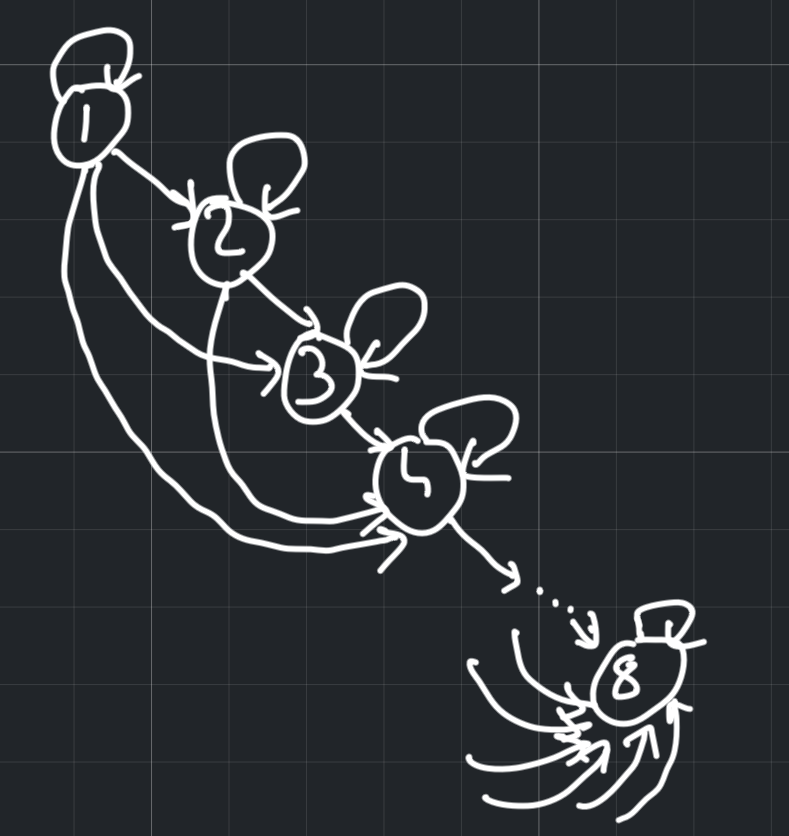

- There is no notion of space. Attention simply acts over a set of vectors. This is why we need to positionally encode tokens.

(the numbers have no clue where they are, unless we tell them)

- Each example across batch dimension is of course processed completely independently and never "talk" to each other

(no inter-batch comm)

- In an "encoder" attention block just delete the single line that does masking with `tril`, allowing all tokens to communicate. This block here is called a "decoder" attention block because it has triangular masking, and is usually used in autoregressive settings, like language modeling.

(here future did NOT talk to past, but in sentiment analysis, we may want future to talk to the past)- remove mask [called enc block]

here we implemented decoder block (mask remains). Mask or no, attention works either ways

- "self-attention" just means that the keys and values are produced from the same source as queries. In "cross-attention", the queries still get produced from x, but the keys and values come from some other, external source (e.g. an encoder module)

Self: keys, queries have same source(x)

If keys, nodes come from dif source and we just get queries from x -> cross attention

- "Scaled" attention additional divides `wei` by 1/sqrt(head_size). This makes it so when input Q,K are unit variance, wei will be unit variance too and Softmax will stay diffuse and not saturate too much. Illustration below

scaling is used to control variance at init. We div by 1/sqrt(head_size) coz, if the values are too big, softmax conv on the largest value

In [ ]:
# without div
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) #* head_size**-0.5

In [ ]:
wei.var() #TOO big

tensor(17.4690)

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1)# gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

This only cares about the highest (last in this case). Last has 0.8, rest are small

In [ ]:
#with div
k = torch.randn(B,T,head_size)
q = torch.randn(B,T,head_size)
wei = q @ k.transpose(-2, -1) * head_size**-0.5

In [ ]:
wei.var() #better (close to 1)

tensor(0.9957)

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])*8, dim=-1) # gets too peaky, converges to one-hot

tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])

In [ ]:
torch.softmax(torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5]), dim=-1) #more even softmax with smaller nums

tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])

Basically we want what goes INTO softmax to not be too extreme at init

FULL:

**Text → Tokens → Token Embeddings → Add Positional Embeddings →
Q, K, V * → Dot Product → Softmax → Weighted Sum → Output**

1. (*) q = x @ Wq
2. k = x @ Wk
3. Attention Scores = q @ kᵀ
4. Softmax each row → Attention Weights
5. Final output = attention weights @ values

MULTI - HEAD attention

- applying multiple attentions in parallel and cat their results

So, when we get emb, we convert 1 token to an embedding of say 64 numbers, and then we div this by num_head, say 4, so we will have 64/4 = 16 per head. Each head will deal with the connections in that stretch and find relations there. Then once passed, we club (add) them all to get 64 dim again

So, adding multiple comm channels, instead of just 1

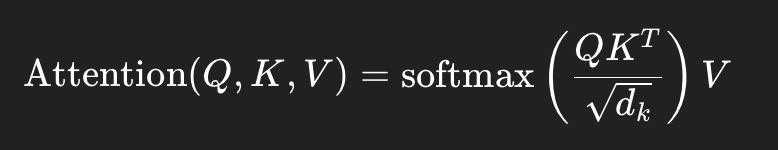

* Q is the matrix of query vectors, with size n × 16 (n = number of tokens in the sentence).
* K is the matrix of key vectors, with size n×16.
* V is the matrix of value vectors, with size n×16.
* dk=16 is the dimensionality of each head (since we split the 64 dimensions into 4 parts, each with 16 dimensions).
* K T is the transpose of the key matrix.

This formula computes how much each word should "attend" to the other words. Specifically:

- The dot product QKT measures the similarity between the query vector for a word and the key vectors for all other words.
- The division by sqrt(dk) is a scaling factor to prevent very large values in the dot product (it helps with stability).
- The softmax function turns the similarity scores into probabilities, i.e., how much attention each word should give to each other word.
- Finally, the softmax output is multiplied by the value vectors
V to produce the weighted sum of values.

After computing attention for each head, the results from all 4 heads are concatenated. Since each head produces a matrix of size n×16, concatenating all 4 heads gives you a matrix of size  n×64 (since 4×16=64).

Concatenated Attention Output=[Att1​;Att2​;Att3​;Att4​]

Final linear transformatn (give it some time with the attention scores)

Finally, the concatenated matrix of size n×64 is passed through a linear transformation (a learned weight matrix WO of size 64×64) to obtain the final output.

Output=Concatenated Attention Output⋅WO​

When the NN gets too deep, we may start over-fitting, so we intro SKIP or residual connections

What these two is (direct path) (comp path) GET ADDed. (add to dist grad equally in back prop)

At init, we can go from supervision to input directly. Over time the blocks kick in

so res connections were added

Then feed-forward (linear layer + act) were added, with 4* input as hidden layer (in the parallel path to the clear-skip)

- Batch-norm | : across batch dim, any neuron will have unit gaussian dist (0 mean, 1 SD output)

Col wise normed, rows are NOT norm

- Layer-norm - : dont norm the cols, norm the rows

this is simpler, no need to maintain buffers and updating and train and test state

In [ ]:
class LayerNorm1d: # (used to be BatchNorm1d)

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

  def __call__(self, x):
    # calculate the forward pass
    xmean = x.mean(1, keepdim=True) # batch mean
    xvar = x.var(1, keepdim=True) # batch variance
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

torch.manual_seed(1337)
module = LayerNorm1d(100)
x = torch.randn(32, 100) # batch size 32 of 100-dimensional vectors
x = module(x)
x.shape

torch.Size([32, 100])

CHANGE FROM ORG paper:

in paper: (add and norm) AFTER (transformatn)

Now: BEFORE

and one right before the final layer

We also added dropouts
1. right before, back into the residual pathway
2. after the multi-head attention
3. after softmax

randomly prevent some of the nodes from communicating

Randomly, every fwd and bck pass, shuts off, some sub-set of neurons. Everything is enabled at test time (every sub-net is trained, and in test, they're all merged into a single ensemble)

We implemented a decoder only model, that just rambles on (does not depend on anything- like say translation, where it has to give output based on input- this will have both enc and decoder)

(triangular mask used in transformer)

In [ ]:
# French to English translation example:

# <--------- ENCODE ------------------><--------------- DECODE ----------------->
# les réseaux de neurones sont géniaux! <START> neural networks are awesome!<END>

What they do is, ENCODER: they take the french -> tokenize -> put transfrmr with NO triangular mask (all tokens talk to each other as much as they want)

once encoded, it comes to the decoder

that is baught in thru cross-attentn (queries from x, keys and values come from side - french). That which comes from the side is fed to every single block of the decoder

NANO GPT

https://github.com/karpathy/nanoGPT/tree/master

- train.py

* all boiler-plate code for training the ntw (we're saving and loading checkpoints, and stuff- complex)

- model.py

**ChatGPT**

Training ChatGPT, stages:

1. Pre-training:
We are training on a large chunk of internet, and trying to get a first, decoder only transformer to blabber text. (what we did here)

this does not respond to questions, it just blabbers (document or question completer). It may or may not complete, it may just ignore and give a random piece of the internet. Totally un-anligned

2. Fine-Tuning:

Align it to be an assistant

https://openai.com/index/chatgpt/

roughly 3 steps:

1. collect training data that looks spec like what a training assistant would do. ques above ans below type. 1000s, not mil/bil. Train on docs that only look like this
2. Let the model respond, and "raters" gauge/rate/judge the model and rank based on pref (reward model)
3. PPO (Proximal Policy Optimization)

policy gradient  reinforcement learning optimizer to finetune this sampling policy- so that the answers that chatGPT now generates are expected to score a high reward acc. the reward model

document completer --> question answerer

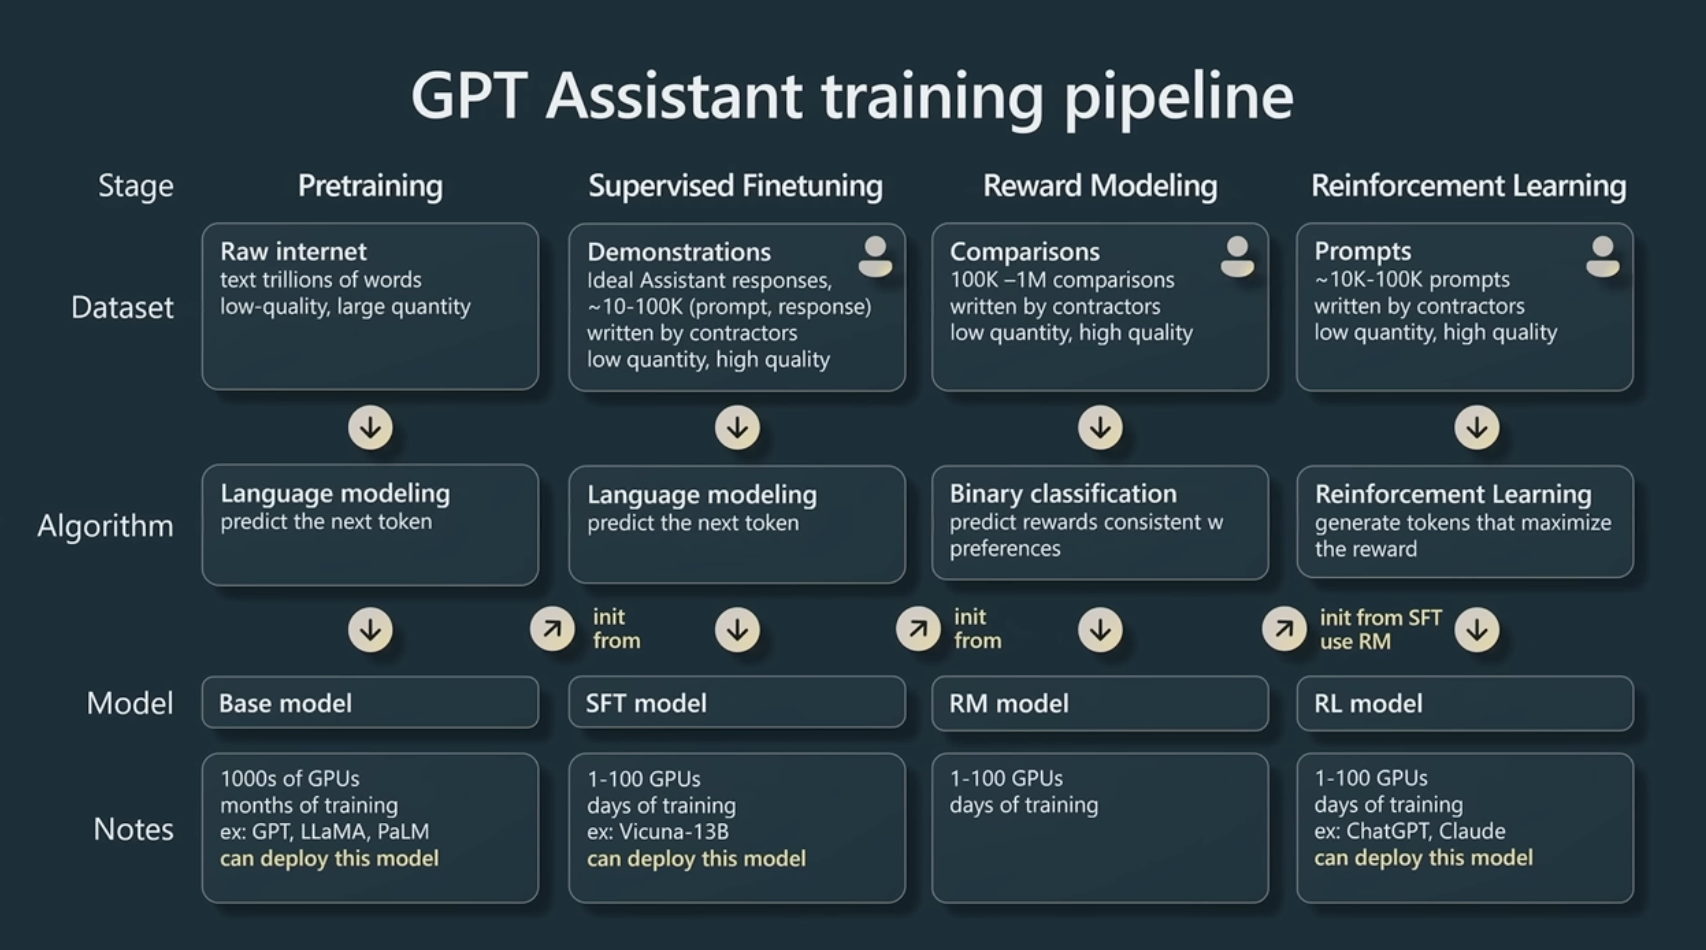

Coding HW

In [ ]:
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }

print(stoi)
print(itos)

import torch
data = torch.tensor(encode(text))
print(data)
n = int(0.9*len(data))
n

--2025-12-25 06:06:01--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.19’

input.txt.19        100%[===================>]   1.06M  --.-KB/s    in 0.1s    

2025-12-25 06:06:02 (9.16 MB/s) - ‘input.txt.19’ saved [1115394/1115394]

{'\n': 0, ' ': 1, '!': 2, '$': 3, '&': 4, "'": 5, ',': 6, '-': 7, '.': 8, '3': 9, ':': 10, ';': 11, '?': 12, 'A': 13, 'B': 14, 'C': 15, 'D': 16, 'E': 17, 'F': 18, 'G': 19, 'H': 20, 'I': 21, 'J': 22, 'K': 23, 'L': 24, 'M': 25, 'N': 26, 'O': 27, 'P': 28, 'Q': 29, 'R': 30, 'S': 31, 'T': 32, 'U': 33, 'V': 34, 'W': 35, 'X': 36, 'Y': 37, 'Z': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44

1003854

In [ ]:
#using lambda
# lambda arguments: expression
# eg:
add_two= lambda a: a+2
print(add_two(3))

torch.manual_seed(1337)

import torch
block_size=5
batch_size=4

!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])
chars = sorted(list(set(text)))
vocab_size = len(chars)
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }

data = torch.tensor(encode(text), dtype=torch.long)

# create a mapping from characters to integers

ix = torch.randint(len(data) - block_size, (batch_size,))
print(ix)
x = torch.stack([data[i:i+block_size] for i in ix])
y = torch.stack([data[i+1:i+block_size+1] for i in ix])
print(x)
print(y)

# Step 1: Get the character at the 1075303rd position
char_at_index = text[1075303]

# Step 2: Convert this character to its corresponding integer index using stoi
index = stoi[char_at_index]

# Step 3: Use this integer index to get the character from itos
char_from_itos = itos[index]

print(char_from_itos)
print(torch.zeros(4))


5
--2025-12-16 11:50:57--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.19’

input.txt.19        100%[===================>]   1.06M  --.-KB/s    in 0.06s   

2025-12-16 11:50:57 (19.3 MB/s) - ‘input.txt.19’ saved [1115394/1115394]

tensor([1075303,  447495,   39813,  668798])
tensor([[44, 43,  8,  0,  0],
        [ 1, 32, 63, 40, 39],
        [31, 10,  0, 32, 39],
        [17, 42, 61, 39, 56]])
tensor([[43,  8,  0,  0, 24],
        [32, 63, 40, 39, 50],
        [10,  0, 32, 39, 49],
        [42, 61, 39, 56, 42]])
f
tensor([0., 0., 0., 0.])


Real code:

1. Self-attention → “Which past characters matter?”
2. Multiple attention heads → “Look at the context in different ways”
3. Feed-forward network → “Think on what we found”
4. Transformer block → “Attention + thinking”
5. Embedding layers → “Turn tokens into vectors”
7. Final projection → “Turn thinking back into character probabilities”

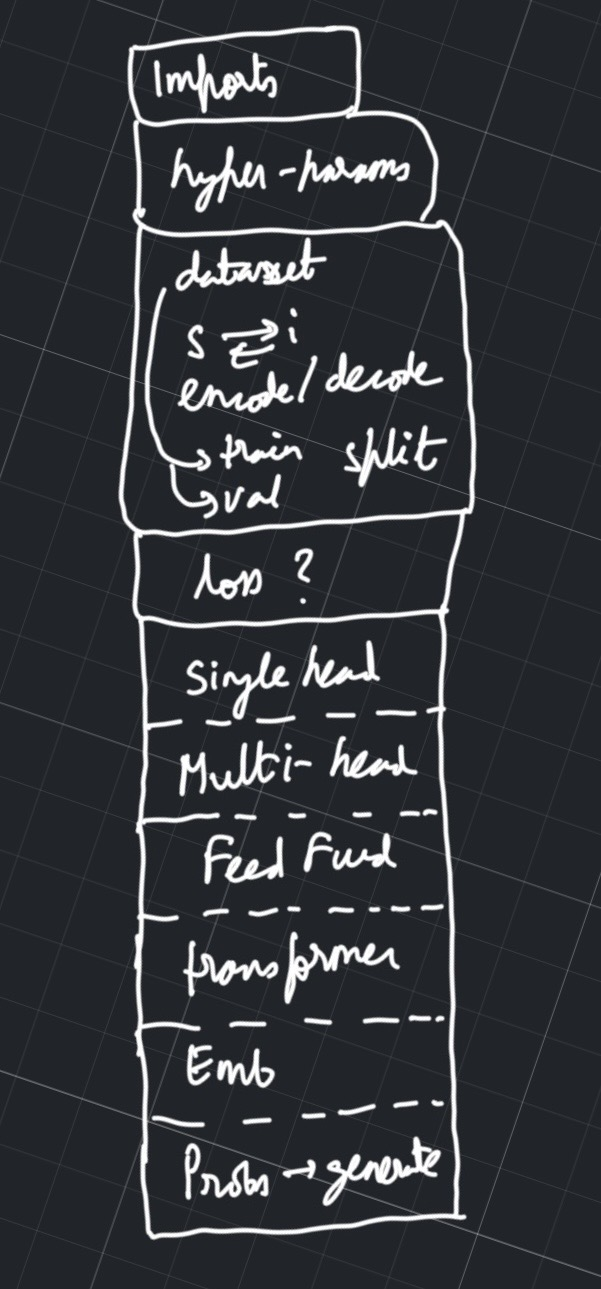

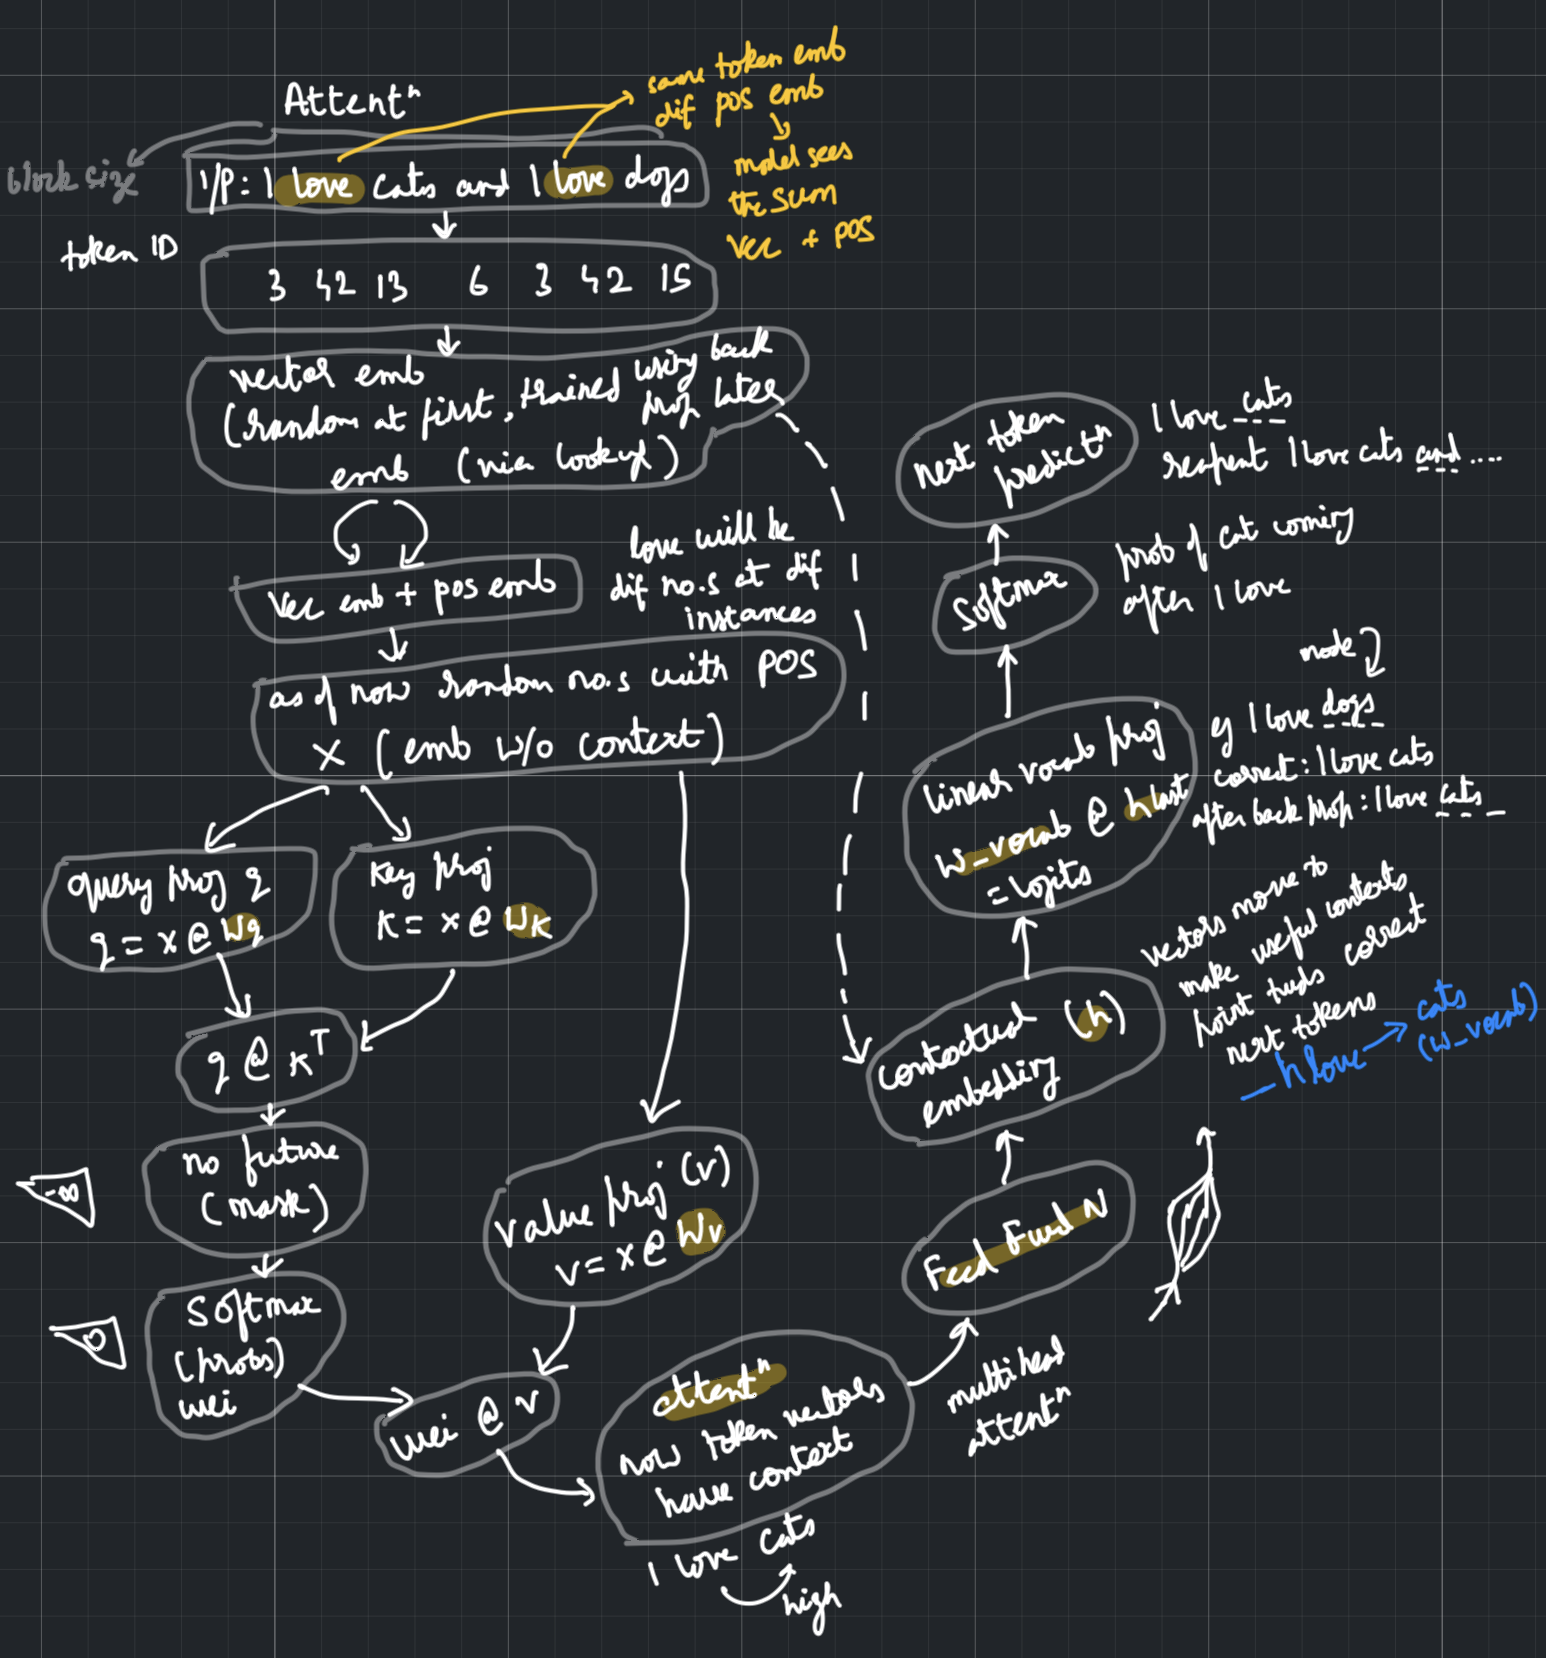

In [ ]:
'''
CLASS stuff:
- init runs ONCE, to construct. It builds. No computation here
- super call nn.Module and enables its methods to work
- dropout AFTER
- def <method> : this part executes (computation here)

┌────────────────────┐
│ __init__           │  ← build the machine
│  - define layers   │
│  - no data         │
└────────────────────┘
           ↓
┌────────────────────┐
│ forward            │  ← run data through machine
│  - no new layers   │
│  - only computation│
└────────────────────┘
'''

In [ ]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100 # Every 100 training iterations, the model pauses training, and calcs loss
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4 # number of Transformer layers (blocks) stacked on top of each other
dropout = 0.0
# ------------

torch.manual_seed(1337)

!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt #dwnld link, shell cmd !
with open('input.txt', 'r', encoding='utf-8') as f: #with ensures the file is automatically closed when done
    text = f.read() # store entire file as a single string called text

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
#char level
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
# seq level
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers | String-char by char-> num
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string | Num-num by num-> Str (no training)

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long) #long means integer, make the data trackable
n = int(0.9*len(data)) # len of 90 of data
train_data = data[:n] #first 90% will be train
val_data = data[n:] # rest is val data

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))#eg 1075303,  447495,   39813..16 nos- (1 for each batch)
    x = torch.stack([data[i:i+block_size] for i in ix]) #array of block_sz by batch_size of x (input)
    y = torch.stack([data[i+1:i+block_size+1] for i in ix]) #same sized array of outputs (targets)
    x, y = x.to(device), y.to(device)
    return x, y

# loss estimator: how off are we?
@torch.no_grad() #dont tack
def estimate_loss():
    out = {}
    model.eval() #eval model on
    for split in ['train', 'val']: #calculates the loss for both the train and val datasets.
        losses = torch.zeros(eval_iters) # one long tensor the size of 200
        for k in range(eval_iters):#For each split (train or val), the function runs for eval_iters iterations to evaluate performance
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean() #give mean of train/ val losses
    model.train() #switch back to train mode (no more eval mode)
    return out #returns mean of train and val loss- just 2 numbers

class Head(nn.Module):# Which past characters matter?
    """ one head of self-attention """
    #(B, T, n_embd) → (B, T, head_size)

    def __init__(self, head_size):
        super().__init__() #Hey PyTorch, I’m creating a new nn module — please track everything
        #whats needed? - keys, qrs, vals
        self.key = nn.Linear(n_embd, head_size, bias=False) #head size = n_embd/heads=64/4=16
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))#make the upper triangle 0s in a blk_sz*blk_sz matrix of 1s
        # 1. make a matrix of ones, 2. make it a lwr triangular, 3. call it tril, and 4. initialize it by calling it reg_buf

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B,T,C = x.shape #make B,T,C x's shape
        k = self.key(x)   # (B,T,C) | we pass x thru layers to get keys,queries
        q = self.query(x) # (B,T,C)
        # compute attention scores ("affinities")
        wei = q @ k.transpose(-2,-1) * C**-0.5 # (B, T, C) @ (B, C, T) -> (B, T, T)
        #self.tril[:T, :T] == 0 makes all the 0s True and 1s False, T is token size, and put -inf wherever True(so that sftmax can make it 0)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)
        wei = F.softmax(wei, dim=-1) # (B, T, T) #softmax over key
        wei = self.dropout(wei)
        # perform the weighted aggregation of the values
        v = self.value(x) # (B,T,C)
        out = wei @ v # (B, T, T) @ (B, T, C) -> (B, T, C)
        return out

class MultiHeadAttention(nn.Module):# Look at the context in different ways
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        # nn.ModuleList allows to store list of nn.Module
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])#create sep heads acc. head_size
        self.proj = nn.Linear(n_embd, n_embd) #combine all sep heads into 1 again
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out)) #first bring it back to org size with proj, then apply dropout to this
        return out

class FeedFoward(nn.Module): #Think on what we found
    """ a simple linear layer followed by a non-linearity """

    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(#run these layers one after the other
            nn.Linear(n_embd, 4 * n_embd),#Each token goes from: n_embd → 4 × n_embd
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),#Compresses back down to original size
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module): #Attention + thinking
    """ Transformer block: communication followed by computation """

    def __init__(self, n_embd, n_head):
        # n_embd: embedding dimension, n_head: the number of heads we'd like
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)#self atten, communicatn
        self.ffwd = FeedFoward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd) #norm embding for stability in deep - norm for sa
        self.ln2 = nn.LayerNorm(n_embd) #norm for feed fwd

    def forward(self, x):
        # x ──► normalize ──► talk to others ──► add back original self
        x = x + self.sa(self.ln1(x)) #normalize it first then compute attetn then add it back to x (residual connectn)
        x = x + self.ffwd(self.ln2(x))
        return x

# super simple bigram model | Emb
class BigramLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()#Turn tokens into vectors
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd) #(vocab_size × n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd) # (block_size × n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)]) #transformer | * removes []
        self.ln_f = nn.LayerNorm(n_embd) # final layer norm
        self.lm_head = nn.Linear(n_embd, vocab_size) #lang model head, w_vocab

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device)) # (T,C) | torch.arrange(5)=[0,1,2,3,4] <- a new tensor
        '''Any tensor you create manually inside forward must be placed on the correct device.'''
        x = tok_emb + pos_emb # (B,T,C) | model sees only this sum not individual
        x = self.blocks(x) # (B,T,C) transformer blocks
        x = self.ln_f(x) # (B,T,C) final norm
        logits = self.lm_head(x) # (B,T,vocab_size) vocab predictn

        if targets is None: #loss calc only for training
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C) #flatten ** Shapes explained in the below cell
            targets = targets.view(B*T) #compare
            loss = F.cross_entropy(logits, targets) #get loss | both are of shape (B*T, C) and (B*T,)

        return logits, loss

    def generate(self, idx, max_new_tokens):#Turn thinking back into character probabilities | INFERENCE
        # idx is (B, T) array of indices in the current context | idx is just words as nums
        # idx is just an integer ID for a token; it is never trained — only the vectors and weights that idx indexes into are learned.
        for _ in range(max_new_tokens): #only new tokens
            # crop idx to the last block_size tokens
            idx_cond = idx[:, -block_size:] #only sees block_size, forget old, backwards
            # get the predictions
            logits, loss = self(idx_cond) #fwd pass, no loss <- calls forward
            # focus only on the last time step | focus on only the last token
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

model = BigramLanguageModel() #create the model
m = model.to(device) # device is CPU or GPU, all parameters now live here
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate) #Adam to learn: given grads update params

for iter in range(max_iters): #training loop

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}") #just measure loss, dont update params

    # sample a batch of data | get data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb) #fwd pass
    optimizer.zero_grad(set_to_none=True) #clear old grads
    loss.backward() #just back, only grads are calc, no param update
    optimizer.step() #update params
    #model is now Trained

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device) #we gen 1 seq, and we start with 1 token
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist())) #start with [1] predict 2000 more, decode to make o/p in eng not nos.


--2025-12-24 02:47:23--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt’

input.txt           100%[===================>]   1.06M  6.31MB/s    in 0.2s    

2025-12-24 02:47:24 (6.31 MB/s) - ‘input.txt’ saved [1115394/1115394]

0.209729 M parameters
step 0: train loss 4.4116, val loss 4.4022
step 100: train loss 2.6568, val loss 2.6670
step 200: train loss 2.5090, val loss 2.5058
step 300: train loss 2.4194, val loss 2.4334
step 400: train loss 2.3501, val loss 2.3568
step 500: train loss 2.2963, val loss 2.3129
step 600: train loss 2.2410, val loss 2.2501
step 700: train loss 2.2057, val loss 2.2191
step 800: train loss 

The flatten part**

In [ ]:
'''

If B = 2, T = 4, and C = 5

logits = [
    [[0.2, 0.5, 0.1, 0.1, 0.1],  # B=0, T=0
     [0.1, 0.6, 0.1, 0.1, 0.1],  # B=0, T=1
     [0.3, 0.4, 0.1, 0.1, 0.1],  # B=0, T=2
     [0.4, 0.2, 0.1, 0.2, 0.1]], # B=0, T=3

    [[0.1, 0.4, 0.3, 0.1, 0.1],  # B=1, T=0
     [0.2, 0.5, 0.1, 0.1, 0.1],  # B=1, T=1
     [0.3, 0.4, 0.1, 0.1, 0.1],  # B=1, T=2
     [0.5, 0.2, 0.1, 0.1, 0.1]]  # B=1, T=3
]

Flattened: (view(B*T, C)): 8,5

logits = [
    [0.2, 0.5, 0.1, 0.1, 0.1],  # (B=0, T=0)
    [0.1, 0.6, 0.1, 0.1, 0.1],  # (B=0, T=1)
    [0.3, 0.4, 0.1, 0.1, 0.1],  # (B=0, T=2)
    [0.4, 0.2, 0.1, 0.2, 0.1],  # (B=0, T=3)
    [0.1, 0.4, 0.3, 0.1, 0.1],  # (B=1, T=0)
    [0.2, 0.5, 0.1, 0.1, 0.1],  # (B=1, T=1)
    [0.3, 0.4, 0.1, 0.1, 0.1],  # (B=1, T=2)
    [0.5, 0.2, 0.1, 0.1, 0.1]   # (B=1, T=3)
]
----------
Targets
B = 2, T = 4

targets = [
    [12, 3, 5, 1],  # B=0 (sequence 1)
    [0, 1, 2, 4]    # B=1 (sequence 2)
]

Flattened: 2*4 = 8

targets = [12, 3, 5, 1, 0, 1, 2, 4]

'''

In [ ]:
'''
text
 ↓ encode
idx (integers)
 ↓ embedding lookup
tok_emb (vectors)
 + pos_emb
 ↓
x (vectors)
 ↓ transformer
 ↓
logits

-------------------
suppose we have a,b,c

1. ---Vocabulary: "a", "b", "c"---

stoi: stoi = { "a": 0, "b": 1, "c": 2}

itos = {0:"a", 1:"b", 2:"c"} Reverse

2. ---Training text: ab---

in our dataset if ab comes: given "a" → predict "b"

3. ---create idx and tragets---

idx     = [0]   # "a"       | idx.shape = (B=1, T=1) -> idx is an integer
targets = [1]   # "b"

----SHAPE----

B, T, C = batch_size, sequence_length, embedding_size

B — Batch size
How many independent sequences we process in parallel.
B = 1

T — Time steps / sequence length
How many tokens are in the input sequence.
idx = [0] or one token. so T = 1

C — Channel / embedding dimension
n_embd.
C = 2

4. ---embedding table:---

vocab_size = 3
n_embd = 2

| token   | embedding   |  Random at first, then trained
| ------- | ----------- |
| 0 ("a") | [0.2, -0.1] |
| 1 ("b") | [0.0,  0.3] |
| 2 ("c") | [-0.2, 0.1] |

shape: Embedding(3, 2)

5. ----Embedding lookup stage----

tok_emb = embedding_table[idx]

idx = 0, so tok_emb = embedding_table[0]

tok_emb = [[0.2, -0.1]]     | shape: (1, 1, 2)  | we have gone from Integer → vector | 0 → [0.2, -0.1]
                                     B.  T.  C

6. ---positional embedding---

let block_size = 4 | so pos: 0,1,2,3

| position | vector        |  Random at first, then trained
| -------- | ------------- |
| 0        | [0.05, 0.05]  |
| 1        | [0.01, -0.02] |
| 2        | [-0.03, 0.04] |
| 3        | [0.02, 0.01]  |

CODE:
pos = torch.arange(T) = [0]
pos_emb = position_embedding_table[0]

so:

pos_emb = [[0.05, 0.05]]
Shape: (T, C) = (1, 2)

7. ---Add token + position embeddings---

x = tok_emb + pos_emb

x = [0.2, -0.1] + [0.05, 0.05] = [0.25, -0.05]

Shape: x.shape = (1, 1, 2) = (B,T,C)

Now, x = [[0.25, -0.05]] ← Transformer processes this

8. ---Transformer/ Language model---

lm_head = Linear(2 → 3)
self.lm_head = nn.Linear(n_embd, vocab_size) = (2,3)


| class | weights     | random at first, then trained
| ----- | ----------- |
| "a"   | [0.1, -0.2] |
| "b"   | [-0.3, 0.4] |
| "c"   | [0.2, 0.1]  |

logits = W @ x + b

Whats the chance that the next token AFTER "a" is?

"a": 0.25*0.1 + (-0.05)*(-0.2) = 0.025 + 0.01 = 0.035

"b": 0.25*(-0.3) + (-0.05)*(0.4) = -0.075 - 0.02 = -0.095

"c": 0.25*0.2 + (-0.05)*0.1 = 0.05 - 0.005 = 0.045

so, logits = [0.035, -0.095, 0.045]

So, we went from [0.25, -0.05] or 2 nos -> [0.035,-0.095,0.045] or 3 nos
we went from n_embd to vocab_size

weights matrix is lm_head which gives us logits as output
---------
when i write:
lm_head = nn.Linear(2, 3)

Pytorch makes:
weight.shape == (3, 2)
bias.shape == (3,)
---------

9. ---Softmax---

Apply softmax on logits

P(a) ≈ 0.34
P(b) ≈ 0.29   ← correct answer but LOW
P(c) ≈ 0.37

10. ----loss computation---

target: targets = [1]  # "b"

cross entropy loss: loss = -log(P("b"))

11. ---Backprop---

loss.backward()

Gradients flow back and update:
- lm_head weights
- embedding vector for token "a"
- position embedding for position 0
❗ Only the used rows are updated

Before: "a" → [0.2, -0.1]

After: "a" → [0.23, -0.07]

12. ---Next training step---

lookup
forward
loss
backward
update

Eventually: "a" → predicts "b" with high probability


'''